Deliverable 5 - Analysis
This notebook performs the required investigations for Deliverable 5
1. Median AirBnb price in Christchurch central
2. In which part of Chch is there a largest gap between short term and long term rental prices
3. Airbnb vs rental properties in each location

In [9]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Connecting to existing SQLite database
con = sqlite3.connect("../rentals.db")

#Load the joined dataset (from deliv_5_sql.ipynb)
joined = pd.read_sql_query("SELECT * FROM joined_quarterly;", con)
joined.head()

,id,quarter,year_month,SA22019_V1_00,price,minimum_nights,number_of_reviews,median_rent,lower_quartile_rent,upper_quartile_rent,total_bonds,active_bonds
0,204050,2025Q4,2025-10-01,320800,96.5,13.0,8,570.0,545.0,688.0,15.0,261.0
1,319770,2025Q4,2025-10-01,325900,112.0,1.0,3,520.0,495.0,600.0,15.0,327.0
2,319770,2026Q1,2026-01-01,325900,198.0,1.0,3,535.0,500.0,575.0,33.0,336.0
3,319770,2026Q2,2026-04-01,325900,198.0,1.0,3,530.0,510.0,640.0,21.0,342.0
4,737452,2025Q4,2025-10-01,333300,330.0,2.0,99,NaN,NaN,NaN,NaN,NaN


TASK 1 - Median AirBnb Price in Christchurch Central

In [10]:
median_chch_central = joined.loc[
    joined["SA22019_V1_00"] == 326600, "price"
].median()

median_chch_central

np.float64(241.0)

The median Airbnb price in christchurch central (Location ID 326600) is $241.

TASK 2 - In which part of Chch can we observe largest gap between short and long term rental prices?

In [11]:
#Calculating the gap bet airbnb prices and long term rental

#Convert weekly to per night rent
joined["long_term_price_per_night"] = joined["median_rent"] / 7

#Working out price gap
joined["price_gap"] = joined["price"] - joined["long_term_price_per_night"]
joined[["SA22019_V1_00", "price", "long_term_price_per_night", "price_gap"]].head()

#Finding the maximum gap
gap_by_sa2 = (
    joined.groupby("SA22019_V1_00")["price_gap"]
    .median()
    .sort_values(ascending=False)
)

gap_by_sa2.head(10)



SA22019_V1_00
322800    266.476190
328800    236.642857
322600    221.964286
324100    210.000000
332700    208.511905
324200    204.714286
322100    201.464286
317400    190.000000
325700    182.904762
330500    180.571429
Name: price_gap, dtype: float64

The SA2 areas in the table above have the largest price gaps. The price gaps are plotted in the boxplot as shown below

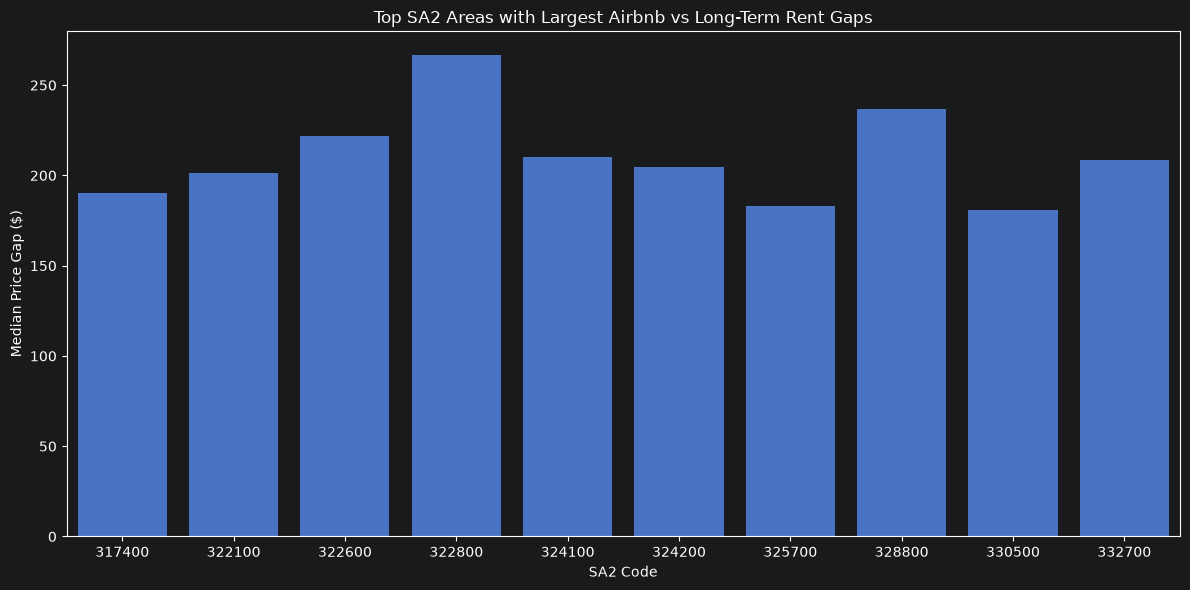

In [12]:
gap_valid = joined.dropna(subset=["median_rent"])

gap_by_sa2 = (
    gap_valid.groupby("SA22019_V1_00")["price_gap"]
    .median()
    .reset_index()
)

top_sa2 = gap_by_sa2.sort_values("price_gap", ascending=False).head(10)
top_sa2

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_sa2,
    x="SA22019_V1_00",
    y="price_gap"
)

plt.title("Top SA2 Areas with Largest Airbnb vs Long-Term Rent Gaps")
plt.ylabel("Median Price Gap ($)")
plt.xlabel("SA2 Code")
plt.tight_layout()
plt.show()

From this plot, it can be seen that SA2 area of 322800 has the largest gap. 322800 is Wigram West.

TASK 3 - Compare how many AirBnbs and rentals in each location

In [13]:
#Checking airbnb counts
airbnb_counts = (
    joined.groupby("SA22019_V1_00")["id"]
    .nunique()
    .reset_index()
    .rename(columns={"id": "airbnb_listings"})
)

#Checking tenancy bonds
tenancy_counts = (
    joined.dropna(subset=["total_bonds"])
    .groupby("SA22019_V1_00")["total_bonds"]
    .sum()
    .reset_index()
    .rename(columns={"total_bonds": "long_term_bonds"})
)

#Combine these into one table to compare no of Airbnbs and rentals
compare_location = airbnb_counts.merge(
    tenancy_counts,
    on="SA22019_V1_00",
    how="left",
)
compare_location.head()

,SA22019_V1_00,airbnb_listings,long_term_bonds
0,316400,5,NaN
1,316500,1,NaN
2,316600,18,441.0
3,316700,28,NaN
4,316800,10,144.0


In [14]:
compare_location["airbnb_to_longterm_ratio"] = (
    compare_location["airbnb_listings"] / compare_location["long_term_bonds"]
)

#sorting..
compare_location.sort_values("airbnb_to_longterm_ratio", ascending=False).head(10)

,SA22019_V1_00,airbnb_listings,long_term_bonds,airbnb_to_longterm_ratio
77,324200,5,24.0,0.208333
95,326000,12,60.0,0.200000
6,317000,17,96.0,0.177083
11,317500,14,84.0,0.166667
51,321600,1,6.0,0.166667
20,318500,4,27.0,0.148148
153,331800,5,36.0,0.138889
133,329800,3,27.0,0.111111
12,317600,3,30.0,0.100000
139,330400,1,12.0,0.083333
